## Quantum Teleportation

Teleportation transfers an unknown quantum state from Alice to Bob using 
a Bell pair and 2 classical bits.

The protocol:
1. Alice and Bob share an entangled pair (A, B)
2. Alice entangles her unknown qubit Q with A, then measures both → gets 2 classical bits
3. Bob applies X and/or Z on his qubit B conditioned on those bits → recovers Q exactly

This notebook uses named quantum registers (Q, A, B) and Qiskit's
`if_test` for classical feed-forward.

In [11]:
from qiskit import QuantumCircuit, transpile,QuantumRegister,ClassicalRegister
from qiskit_aer import Aer,AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from qiskit.result import marginal_distribution
import random
from math import pi
from qiskit.circuit.library import UGate
from qiskit.visualization import array_to_latex
from IPython.display import display
%matplotlib inline

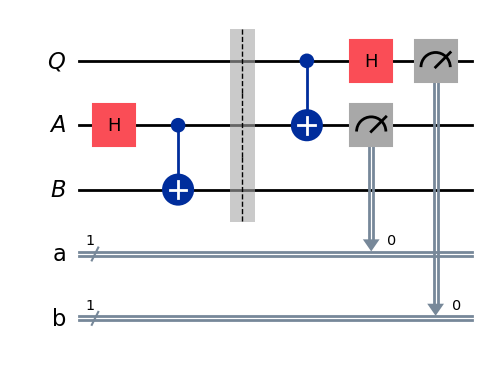

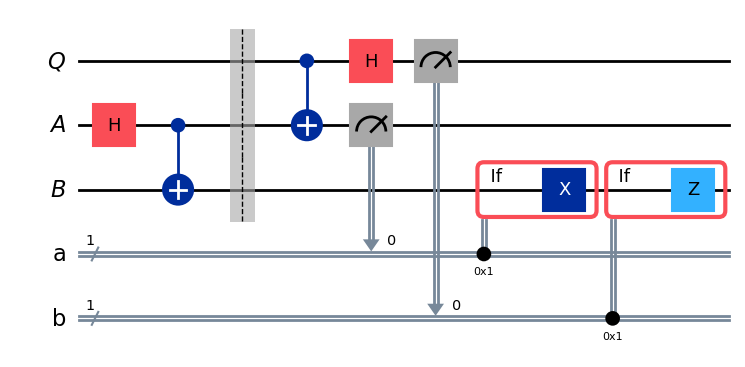

In [6]:
#defining Quantum and Classical registers
qubit = QuantumRegister(1,"Q")
ebit0 = QuantumRegister(1,"A")
ebit1 = QuantumRegister(1,"B")
a = ClassicalRegister(1,"a")
b = ClassicalRegister(1,"b")
protocol = QuantumCircuit(qubit,ebit0,ebit1,a,b)

#entanglemet
protocol.h(ebit0)
protocol.cx(ebit0,ebit1)
protocol.barrier()

#Alice's operations
protocol.cx(qubit,ebit0)
protocol.h(qubit)
protocol.measure(ebit0,a)
protocol.measure(qubit,b)

initial_circuit = protocol.draw(output='mpl')
initial_circuit.savefig("initial_circuit.png")

#bob's operations
with protocol.if_test((a, 1)):
    protocol.x(ebit1)
with protocol.if_test((b, 1)):
    protocol.z(ebit1)
    

circuit = protocol.draw(output='mpl')
circuit.savefig("teleportation_circuit.png")